# analysis.host-range

In this analysis, we want to quantify the relationships between bacteria host range and other ranges in the system (virus host range, bacteria range, virus range.)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import powerlaw
import networkx as nx
from scipy.stats import kruskal, mannwhitneyu
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
si = DaforferDB(conf['si'])
si.toc()

/home/bcz/miniconda3/envs/miripvir25/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


┌──────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│   name   │                                                        description                                                        │
│ varchar  │                                                          varchar                                                          │
├──────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ TableS1  │ Table S1: Library sites and context                                                                                       │
│ TableS2  │ This table summarizes most of the information of our detected OTUs, including host_range, site_range, habitat_range, etc. │
│ TableS3  │ Site-level diversity and number of cooccurring virus-bacteria                                                             │
│ TableS4  │ Habitat-level diversity and 

In [2]:
db.toc().df()

,name,description
0,D_bacteriaHits,This table contains all the MOTUS hits obtaine...
1,D_PABHits,This table contains all the PAB MOTUS hits. It...
2,D_sites,This table contains key information about each...
3,d_TableS1,Table S1: Library sites and context
4,D_PABOTUs,This table summarizes most of the information ...
5,D_virusHits,This table contains all the virus hits. It con...
6,D_Site_level_div,Site-level diversity and number of cooccurring...
7,D_Habitat_level_div,Habitat-level diversity and number of cooccurr...
8,P_PABtaxonomy,Number of PAB hits belonging to each different...
9,D_PABTypeCounts,Occurrences of the different kinds of PABs


## Host range calculations

We compute the host range simply as the number of hosts that a given bacteria can infect.

In [3]:
metadata = db.conn.sql('SELECT * FROM D_sites').df()
bacteria_hits = db.conn.sql('SELECT * FROM D_PABHits').df()
bacteria_hits = pd.merge(metadata, bacteria_hits, on='library', how='left').dropna(subset='taxid')
bacteria_hits['taxid'] = bacteria_hits['taxid'].astype(int)
bacteria_host_range = bacteria_hits.value_counts(
    ['host_taxon', 'scientific_name']
    ).reset_index().value_counts(
        ['scientific_name']
    ).reset_index().rename(columns={'count': 'host_range'})

bacteria_host_range

,scientific_name,host_range
0,Frigoribacterium sp. Leaf164,22
1,Pseudomonas lutea,16
2,Rhodococcoides fascians,15
3,Methylobacterium sp. Leaf125,14
4,Duffyella gerundensis,14
...,...,...
122,Erwinia mallotivora,1
123,Enterobacter kobei,1
124,Duganella sp. CF458,1
125,Duganella sp. CF402,1


In [4]:
virus_hits = db.conn.sql('SELECT * FROM D_virusHits').df()
virus_hits = pd.merge(metadata, virus_hits, on='library', how='left')
# virus_hits['taxid'] = virus_hits['taxid'].astype(int)
virus_host_range = virus_hits.value_counts(
    ['host_taxon', 'scientific_name']
    ).reset_index().value_counts(
        ['scientific_name']
    ).reset_index().rename(columns={'count': 'host_range'})

virus_host_range

,scientific_name,host_range
0,Cucumber mosaic virus RNA 3,83
1,Tobacco mild green mosaic virus,65
2,Pelargonium zonate spot virus RNA 3,58
3,Tobacco mosaic virus,52
4,Rubus chlorotic mottle virus,50
...,...,...
153,Potato leafroll virus,1
154,Petunia asteroid mosaic virus,1
155,Cucumber leaf spot virus,1
156,Pepper cryptic virus 2,1


In [5]:
bacteria_host_range['kingdom'] = 'bacteria'
virus_host_range['kingdom'] = 'virus'
host_range = pd.concat([bacteria_host_range, virus_host_range])

db.save_dataframe(host_range, "D_hostRanges", "Bacteria and virus host-ranges")
host_range

Saved D_hostRanges to db.2025-10-27


,scientific_name,host_range,kingdom
0,Frigoribacterium sp. Leaf164,22,bacteria
1,Pseudomonas lutea,16,bacteria
2,Rhodococcoides fascians,15,bacteria
3,Methylobacterium sp. Leaf125,14,bacteria
4,Duffyella gerundensis,14,bacteria
...,...,...,...
153,Potato leafroll virus,1,virus
154,Petunia asteroid mosaic virus,1,virus
155,Cucumber leaf spot virus,1,virus
156,Pepper cryptic virus 2,1,virus


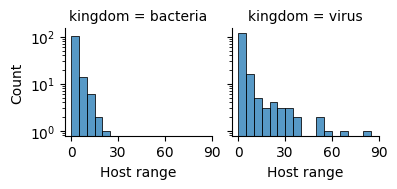

In [6]:

max_range = (host_range['host_range'].max() // 5) + 2
bins = np.arange(0, max_range * 5, 5)
g = sns.displot(data=host_range, x='host_range', col='kingdom', height=2.0, bins=bins)
g.axes[0, 0].set_yscale('log')
g.axes[0, 0].set_xticks([0, 30, 60, 90])
g.set_xlabels("Host range")
g.savefig("figures/displot.host-range.colbykingdom.svg")

## Host range distributions

The results that we observe indicate that a very few virus or bacteria have a remarkable host-range, while most of them have very few hits. This could mean that the host-range might be distributed according to a heavy tailed distribution in organism-host network. We use the `powerlaw` package to compute whether the data here could be fitted to a heavy tailed model better than a simple exponential model.

In [7]:
heavy_tail_model_lrtest = []

pwl_virus = powerlaw.Fit(data=virus_host_range['host_range'], discrete=True)
pwl_bacteria = powerlaw.Fit(data=bacteria_host_range['host_range'], discrete=True)

R, p = pwl_virus.distribution_compare('power_law', 'exponential')
heavy_tail_model_lrtest.append({'distribution':'virus', 'dist1': 'power-law', 'dist2': 'exponential', 'R':R, 'p-value':p})
R, p = pwl_virus.distribution_compare('lognormal', 'exponential')
heavy_tail_model_lrtest.append({'distribution':'virus', 'dist1': 'lognormal', 'dist2': 'exponential', 'R':R, 'p-value':p})
R, p = pwl_bacteria.distribution_compare('power_law', 'exponential')
heavy_tail_model_lrtest.append({'distribution':'bacteria', 'dist1': 'power-law', 'dist2': 'exponential', 'R':R, 'p-value':p})
R, p = pwl_bacteria.distribution_compare('lognormal', 'exponential')
heavy_tail_model_lrtest.append({'distribution':'bacteria', 'dist1': 'lognormal', 'dist2': 'exponential', 'R':R, 'p-value':p})
heavy_tail_model_lrtest = pd.DataFrame.from_records(heavy_tail_model_lrtest)

db.save_dataframe(
    heavy_tail_model_lrtest, table_name="T_hostRangeslogRatioTest", description="Power-law, Lognormal, and Exponential fit log-ratio test"
)

heavy_tail_model_lrtest

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Saved T_hostRangeslogRatioTest to db.2025-10-27


,distribution,dist1,dist2,R,p-value
0,virus,power-law,exponential,27.126482,0.001078
1,virus,lognormal,exponential,28.582261,0.000111
2,bacteria,power-law,exponential,1.110093,0.776804
3,bacteria,lognormal,exponential,3.550244,0.171460


In [8]:
R, p = pwl_virus.distribution_compare('power_law', 'exponential')
R, p = pwl_bacteria.distribution_compare('lognormal', 'exponential')
heavy_tail_model_fits = pd.DataFrame.from_records([
    {"distribution": "bacteria", "model": "exponential", "log-likelihood": pwl_bacteria.exponential.loglikelihood},
    {"distribution": "bacteria", "model": "lognormal", "log-likelihood": pwl_bacteria.lognormal.loglikelihood},
    {"distribution": "bacteria", "model": "power-law", "log-likelihood": pwl_bacteria.power_law.loglikelihoods(pwl_bacteria.data).sum()},
    {"distribution": "virus", "model": "exponential", "log-likelihood": pwl_virus.exponential.loglikelihood},
    {"distribution": "virus", "model": "lognormal", "log-likelihood": pwl_virus.lognormal.loglikelihood},
    {"distribution": "virus", "model": "power-law", "log-likelihood": pwl_virus.power_law.loglikelihoods(pwl_virus.data).sum()},
])

db.save_dataframe(
    heavy_tail_model_fits, table_name="T_hostRangesFits", description="Power-law, Lognormal, and exponential fits"
)
heavy_tail_model_fits

Saved T_hostRangesFits to db.2025-10-27


,distribution,model,log-likelihood
0,bacteria,exponential,-157.501553
1,bacteria,lognormal,-153.951309
2,bacteria,power-law,-156.391460
3,virus,exponential,-304.738231
4,virus,lognormal,-276.155970
5,virus,power-law,-277.611749


In [9]:
TableS8 = pd.merge(
    pd.merge(
        heavy_tail_model_lrtest,
        heavy_tail_model_fits.query('model == "power-law" or model == "lognormal"'), 
        left_on=['distribution', 'dist1'], 
        right_on=['distribution', 'model']
    ),
    heavy_tail_model_fits.query('model == "exponential"'),
    left_on=['distribution', 'dist2'], 
    right_on=['distribution', 'model']
).rename(columns={'distribution': 'kingdom', 'log-likelihood_x': 'dist1_loglikelihood','log-likelihood_y': 'dist2_loglikelihood',})[
    ['kingdom', 'dist1', 'dist2', 'R', 'p-value', 'dist1_loglikelihood', 'dist2_loglikelihood']
]
si.save_dataframe(
    TableS8, table_name="TableS8", description="Host-range long-tail model fits"
)
TableS8

Saved TableS8 to si.2025-10-27


,kingdom,dist1,dist2,R,p-value,dist1_loglikelihood,dist2_loglikelihood
0,virus,power-law,exponential,27.126482,0.001078,-277.611749,-304.738231
1,virus,lognormal,exponential,28.582261,0.000111,-276.155970,-304.738231
2,bacteria,power-law,exponential,1.110093,0.776804,-156.391460,-157.501553
3,bacteria,lognormal,exponential,3.550244,0.171460,-153.951309,-157.501553


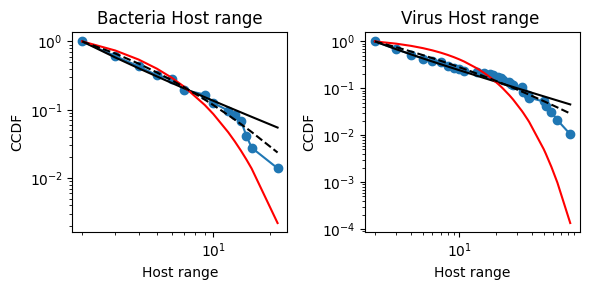

In [10]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(6, 3)
pwl_bacteria.plot_ccdf(ax=ax[0], marker='o')
pwl_bacteria.power_law.plot_ccdf(ax=ax[0], color='black', linestyle='-')
pwl_bacteria.exponential.plot_ccdf(ax=ax[0], color='red', linestyle='-')
pwl_bacteria.lognormal.plot_ccdf(ax=ax[0], color='black', linestyle='--')

pwl_virus.plot_ccdf(ax=ax[1], marker='o')
pwl_virus.power_law.plot_ccdf(ax=ax[1], color='black', linestyle='-')
pwl_virus.exponential.plot_ccdf(ax=ax[1], color='red', linestyle='-')
pwl_virus.lognormal.plot_ccdf(ax=ax[1], color='black', linestyle='--')

ax[0].set_title("Bacteria Host range")
ax[1].set_title("Virus Host range ")

ax[0].set_xlabel("Host range")
ax[1].set_xlabel("Host range")

ax[0].set_ylabel("CCDF")
ax[1].set_ylabel("CCDF")

fig.tight_layout()
fig.savefig("figures/ccdfplot.host-range-distributions.svg")

**Results**: It seems that virus are distributed following some sort of heavy-tailed degree distribution, while bacteria are not clearly following such a type of distribution.

## Host Range and Cooccurrence



In [11]:
cooccurrence_network = nx.read_graphml("output/network.coocurrence.virusbact-bylibrary.trans.graphml")
cooccurrence_network.number_of_edges()

57

In [12]:
cooccurrence_network.nodes()

NodeView(('Beet chlorosis virus', 'Duffyella gerundensis', 'Frigoribacterium sp. Leaf164', 'Pseudomonas oryzihabitans', 'Rhodococcoides fascians', 'Beet mild yellowing virus', 'Beet western yellows virus', 'Agrobacterium tumefaciens', 'Arthrobacter sp. Leaf234', 'Pseudomonas sp. Leaf127', 'Sphingomonas sp. Leaf20', 'Cucumber mosaic virus RNA 3', 'Maize dwarf mosaic virus', 'Parietaria mottle virus RNA 3', 'Xanthomonas campestris', 'Pelargonium zonate spot virus RNA 3', 'Pepper mild mottle virus', 'Frigoribacterium sp. Leaf186', 'Pantoea ananatis', 'Sanguibacter sp. Leaf3', 'Rubus chlorotic mottle virus', 'Tobacco mild green mosaic virus', 'Methylobacterium sp. Leaf125', 'Pseudomonas punonensis', 'Rhizobium sp. Leaf311', 'Sphingomonas sp. Leaf208', 'Xylophilus sp. Leaf220', 'Tobacco mosaic virus', 'Curtobacterium flaccumfaciens', 'Rhizobium sp. NFR03', 'Tomato aspermy virus RNA 3', 'Tomato mosaic virus', 'Turnip yellows virus', 'Watermelon mosaic virus', 'Bradyrhizobium elkanii', 'Youca

We compute host-ranges

In [13]:
virus_host_range = virus_hits.drop_duplicates(
    subset=['scientific_name', 'host_taxon']
).value_counts('scientific_name').reset_index()
bacteria_host_range = bacteria_hits.drop_duplicates(
    subset=['scientific_name', 'host_taxon']
).value_counts('scientific_name').reset_index()
virus_host_range['kingdom'] = 'virus'
bacteria_host_range['kingdom'] = 'bacteria'
host_range = pd.concat([virus_host_range, bacteria_host_range])
host_range

,scientific_name,count,kingdom
0,Cucumber mosaic virus RNA 3,83,virus
1,Tobacco mild green mosaic virus,65,virus
2,Pelargonium zonate spot virus RNA 3,58,virus
3,Tobacco mosaic virus,52,virus
4,Rubus chlorotic mottle virus,50,virus
...,...,...,...
122,Erwinia mallotivora,1,bacteria
123,Enterobacter kobei,1,bacteria
124,Duganella sp. CF458,1,bacteria
125,Duganella sp. CF402,1,bacteria


In [14]:
hits = pd.concat([
    bacteria_hits[['host_taxon', 'scientific_name']],
    virus_hits[['host_taxon', 'scientific_name']],
]).drop_duplicates(['host_taxon', 'scientific_name'], keep='first')
hits

,host_taxon,scientific_name
1,Brassica oleracea,Pseudomonas endophytica
2,Brassica oleracea,Micrococcus luteus
5,Sisymbrium runcinatum,Sphingomonas sp. Leaf20
6,Sisymbrium runcinatum,Rhodococcoides fascians
7,Sisymbrium runcinatum,Sphingomonas sp. Leaf17
...,...,...
1649,Zea mays,Rubus chlorotic mottle virus
1650,Zea mays,Tomato mosaic virus
1651,Zea mays,Cucumber mosaic virus RNA 3
1653,Zea mays,Zucchini yellow mosaic virus


In [15]:

organism_cooccurrences = []
for hit in hits.scientific_name.unique():
    if hit in cooccurrence_network.nodes():
        organism_cooccurrences.append({
            "scientific_name": hit,
            "cooc_net_degree": cooccurrence_network.degree[hit]
        })
    else:
        organism_cooccurrences.append({
            "scientific_name": hit,
            "cooc_net_degree": 0
        })
organism_cooccurrences = pd.DataFrame.from_records(organism_cooccurrences)
organism_cooccurrences['cooc_net_degree'] = organism_cooccurrences['cooc_net_degree'].fillna(0)
organism_cooccurrences['does_cooccur'] = organism_cooccurrences['cooc_net_degree'] > 0
host_range_cooccurrence = pd.merge(organism_cooccurrences, host_range,  on='scientific_name')

host_range_cooccurrence
    

,scientific_name,cooc_net_degree,does_cooccur,count,kingdom
0,Pseudomonas endophytica,0,False,2,bacteria
1,Micrococcus luteus,0,False,3,bacteria
2,Sphingomonas sp. Leaf20,1,True,9,bacteria
3,Rhodococcoides fascians,7,True,15,bacteria
4,Sphingomonas sp. Leaf17,0,False,1,bacteria
...,...,...,...,...,...
280,Alfalfa enamovirus 1,0,False,1,virus
281,Pea enation mosaic virus 1,0,False,1,virus
282,Atractylodes mild mottle virus,0,False,1,virus
283,Pepper cryptic virus 2,0,False,1,virus


In [16]:
# host_range_cooccurrence = pd.merge(cooccurrence, host_range, left_on='name', right_on='scientific_name', how='right')
# host_range_cooccurrence['does_cooccur'] = (1-host_range_cooccurrence['name'].isna()).astype(bool).astype(str)
# host_range_cooccurrence['degree'] = host_range_cooccurrence['degree'].fillna(0)
# host_range_cooccurrence



In [17]:
host_range_cooccurrence = host_range_cooccurrence.rename(columns={'count': 'host_range'})[[
    'scientific_name', 'kingdom', 'cooc_net_degree', 'host_range', 'does_cooccur'
]]

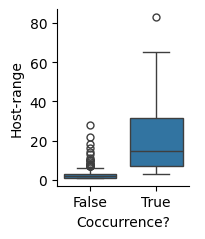

In [18]:
g = sns.catplot(host_range_cooccurrence, x='does_cooccur', y='host_range',  kind='box', height=2.5, aspect=0.8)
g.set_xlabels("Coccurrence?")
g.set_ylabels("Host-range")

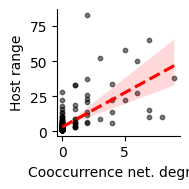

In [19]:
g = sns.lmplot(
    host_range_cooccurrence, x='cooc_net_degree', y='host_range', height=2.0,
    scatter_kws={'alpha':0.5, 's':10, 'color': 'black'}, line_kws={'color': 'red', 'linestyle':'--'}
)
g.set_xlabels("Cooccurrence net. degree")
g.set_ylabels("Host range")
g.savefig("figures/linreg.coocurrence-degree.host-range.svg")

In [20]:
test = stats.linregress(host_range_cooccurrence['cooc_net_degree'], host_range_cooccurrence['host_range'])

test_results = pd.DataFrame.from_records([
    {"key": "title", "value":"Cooccurrence versus host-range"},
    {"key": "test-type", "value":"Regression"},
    {"key": "H0", "value":""},
    {"key": "H1", "value":""},
    {"key": "p-value", "value": test.pvalue}, #type: ignore
    {"key": "significative", "value": test.pvalue < 0.05}, #type: ignore
    {"key": "intercept", "value": test.intercept}, #type: ignore
    {"key": "slope", "value": test.slope}, #type: ignore
    {"key": "r-value", "value": test.rvalue}, #type: ignore
    {"key": "R2", "value": test.rvalue ** 2} #type: ignore

])

db.save_dataframe(
    test_results, table_name="T_coocHostRangeCorr", 
    description="Correlation test between number of cooccurrences and the host-range"
)
test_results


Saved T_coocHostRangeCorr to db.2025-10-27


,key,value
0,title,Cooccurrence versus host-range
1,test-type,Regression
2,H0,
3,H1,
4,p-value,0.0
5,significative,True
6,intercept,3.217847
7,slope,4.85012
8,r-value,0.647992
9,R2,0.419893


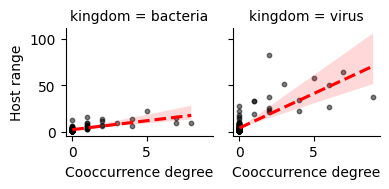

In [21]:
g = sns.lmplot(
    host_range_cooccurrence, x='cooc_net_degree', y='host_range', height=2.0, col='kingdom',
    scatter_kws={'alpha':0.5, 's':10, 'color': 'black'}, line_kws={'color': 'red', 'linestyle':'--'}
)
g.set_xlabels("Cooccurrence degree")
g.set_ylabels("Host range")
g.savefig("figures/linreg.coocurrence-degree.host-range.colbykingdom.svg")

In [22]:
test = stats.linregress(
    host_range_cooccurrence.query('kingdom == "virus"')['cooc_net_degree'], 
    host_range_cooccurrence.query('kingdom == "virus"')['host_range'])

test_results = pd.DataFrame.from_records([
    {"key": "title", "value":"Cooccurrence versus host-range in virus"},
    {"key": "test-type", "value":"Regression"},
    {"key": "H0", "value":""},
    {"key": "H1", "value":""},
    {"key": "p-value", "value": test.pvalue}, #type: ignore
    {"key": "significative", "value": test.pvalue < 0.05}, #type: ignore
    {"key": "intercept", "value": test.intercept}, #type: ignore
    {"key": "slope", "value": test.slope}, #type: ignore
    {"key": "r-value", "value": test.rvalue}, #type: ignore
    {"key": "R2", "value": test.rvalue ** 2} #type: ignore

])

db.save_dataframe(
    test_results, table_name="T_coocHostRangeCorrVir", 
    description="Correlation test between number of cooccurrences and the host-range in Virus"
)
test_results


Saved T_coocHostRangeCorrVir to db.2025-10-27


,key,value
0,title,Cooccurrence versus host-range in virus
1,test-type,Regression
2,H0,
3,H1,
4,p-value,0.0
5,significative,True
6,intercept,4.09352
7,slope,7.424981
8,r-value,0.765305
9,R2,0.585692


In [23]:
test = stats.linregress(
    host_range_cooccurrence.query('kingdom == "bacteria"')['cooc_net_degree'], 
    host_range_cooccurrence.query('kingdom == "bacteria"')['host_range'])

test_results = pd.DataFrame.from_records([
    {"key": "title", "value":"Cooccurrence versus host-range in Bacteria"},
    {"key": "test-type", "value":"Regression"},
    {"key": "H0", "value":""},
    {"key": "H1", "value":""},
    {"key": "p-value", "value": test.pvalue}, #type: ignore
    {"key": "significative", "value": test.pvalue < 0.05}, #type: ignore
    {"key": "intercept", "value": test.intercept}, #type: ignore
    {"key": "slope", "value": test.slope}, #type: ignore
    {"key": "r-value", "value": test.rvalue}, #type: ignore
    {"key": "R2", "value": test.rvalue ** 2} #type: ignore

])

db.save_dataframe(
    test_results, table_name="T_coocHostRangeCorrBact", 
    description="Correlation test between number of cooccurrences and the host-range in Bacteria"
)
test_results


Saved T_coocHostRangeCorrBact to db.2025-10-27


,key,value
0,title,Cooccurrence versus host-range in Bacteria
1,test-type,Regression
2,H0,
3,H1,
4,p-value,0.0
5,significative,True
6,intercept,2.285935
7,slope,1.92432
8,r-value,0.716642
9,R2,0.513575


In [24]:
test_results = []
test = mannwhitneyu(
    host_range_cooccurrence.query('does_cooccur == True')['host_range'],
    host_range_cooccurrence.query('does_cooccur == False')['host_range'],
)

test_results.append(
    {
        "organisms": "all", "statistic": test.statistic, "p-value": test.pvalue
    }
)
test = mannwhitneyu(
    host_range_cooccurrence.query('does_cooccur == True').query('kingdom == "bacteria"')['host_range'],
    host_range_cooccurrence.query('does_cooccur == False').query('kingdom == "bacteria"')['host_range'],
)
test_results.append(
    {
        "organisms": "bacteria", "statistic": test.statistic, "p-value": test.pvalue
    }
)
mannwhitneyu(
    host_range_cooccurrence.query('does_cooccur == True').query('kingdom == "virus"')['host_range'],
    host_range_cooccurrence.query('does_cooccur == False').query('kingdom == "virus"')['host_range'],
)
test_results.append(
    {
        "organisms": "virus", "statistic": test.statistic, "p-value": test.pvalue
    }
)
test_results = pd.DataFrame.from_records(test_results)

db.save_dataframe(
    test_results, table_name="T_coocHostRangeMW", 
    description="Multiple Mann-Whitney tests on the Host-range of cooccurring organisms versus not cooccurring organisms"
)
test_results

Saved T_coocHostRangeMW to db.2025-10-27


,organisms,statistic,p-value
0,all,8945.5,6.856033e-21
1,bacteria,2230.5,6.370211e-13
2,virus,2230.5,6.370211e-13


In [25]:
si.save_dataframe(
    host_range_cooccurrence, 'TableS9',
    'Host range and cooccurrence network degree'
)
host_range_cooccurrence

Saved TableS9 to si.2025-10-27


,scientific_name,kingdom,cooc_net_degree,host_range,does_cooccur
0,Pseudomonas endophytica,bacteria,0,2,False
1,Micrococcus luteus,bacteria,0,3,False
2,Sphingomonas sp. Leaf20,bacteria,1,9,True
3,Rhodococcoides fascians,bacteria,7,15,True
4,Sphingomonas sp. Leaf17,bacteria,0,1,False
...,...,...,...,...,...
280,Alfalfa enamovirus 1,virus,0,1,False
281,Pea enation mosaic virus 1,virus,0,1,False
282,Atractylodes mild mottle virus,virus,0,1,False
283,Pepper cryptic virus 2,virus,0,1,False


## Host-range by habitats

In this block, we want to check whether hosts exhibit different host-ranges across different habitats.

We will:

1. Compute the per-habitat host range from the data.
2. Generate vectors containing that data
3. Run an ANOVA test
4. Save the result

### Step 1: Compute per-habitat host-range

We simply add the habitat inside the host-range.

In [26]:

# bacteria_host_range_byhabitat = bacteria_hits.value_counts(
#     ['host_taxon', 'habitat', 'scientific_name']
#     ).reset_index().value_counts(
#         ['scientific_name', 'habitat']
#     ).reset_index().rename(columns={'count': 'host_range'})

# virus_host_range_byhabitat = virus_hits.value_counts(
#     ['host_taxon', 'habitat', 'scientific_name']
#     ).reset_index().value_counts(
#         ['scientific_name', 'habitat']
#     ).reset_index().rename(columns={'count': 'host_range'})

# bacteria_host_range_byhabitat['kingdom'] = 'bacteria'
# virus_host_range_byhabitat['kingdom'] = 'virus'
# host_range_byhabitat = pd.concat(
#     [
#         bacteria_host_range_byhabitat, 
#         virus_host_range_byhabitat
#     ]
# )

# # db.save_dataframe(host_range, "Host_ranges", "Bacteria and virus host-ranges")
# host_range_byhabitat


In [27]:
virus_host_range_byhabitat_pvt = db.conn.sql('SELECT * FROM D_virusOTUs').df()[['scientific_name', 'Crop_HR', 'Edge_HR', 'Oak_HR', 'Wasteland_HR']]
virus_host_range_byhabitat_pvt['kingdom'] = 'virus'

bact_host_range_byhabitat_pvt = db.conn.sql('SELECT * FROM D_PABOTUs').df()[['scientific_name', 'Crop_HR', 'Edge_HR', 'Oak_HR', 'Wasteland_HR']]
bact_host_range_byhabitat_pvt['kingdom'] = 'bacteria'

host_range_byhabitat_pvt = pd.concat([virus_host_range_byhabitat_pvt, bact_host_range_byhabitat_pvt])
host_range_byhabitat_pvt



,scientific_name,Crop_HR,Edge_HR,Oak_HR,Wasteland_HR,kingdom
0,Barley yellow dwarf virus - GAV,4.0,3.0,0.0,0.0,virus
1,Barley yellow dwarf virus - PAS,4.0,2.0,0.0,1.0,virus
2,Barley yellow dwarf virus - PAV,8.0,2.0,0.0,1.0,virus
3,Cucumber mosaic virus RNA 3,13.0,45.0,32.0,16.0,virus
4,Rubus chlorotic mottle virus,13.0,39.0,4.0,4.0,virus
...,...,...,...,...,...,...
122,Azospirillum lipoferum,0.0,0.0,0.0,1.0,bacteria
123,Arthrobacter sp. OY3WO11,1.0,0.0,0.0,0.0,bacteria
124,Arthrobacter sp. SPG23,0.0,1.0,0.0,0.0,bacteria
125,Microbacterium ginsengisoli,1.0,0.0,0.0,0.0,bacteria


An issue that could affect the calculations would be the absence of zeros in those organisms that were not detected in a given habitat. Therefore, we neeed to take them into account. We can do this by pivoting our datable and filling with zeros.

In [28]:
host_range_byhabitat_melt = host_range_byhabitat_pvt.melt(id_vars=['scientific_name', 'kingdom'], value_vars=['Crop_HR', 'Edge_HR', 'Oak_HR', 'Wasteland_HR'])
host_range_byhabitat_melt['variable'] = host_range_byhabitat_melt['variable'].apply(lambda x: x.replace('_HR', ''))
host_range_byhabitat_melt = host_range_byhabitat_melt.rename(columns={'variable':'habitat', 'value':'host_range'}).query('host_range != 0.0').copy()
host_range_byhabitat_melt

,scientific_name,kingdom,habitat,host_range
0,Barley yellow dwarf virus - GAV,virus,Crop,4.0
1,Barley yellow dwarf virus - PAS,virus,Crop,4.0
2,Barley yellow dwarf virus - PAV,virus,Crop,8.0
3,Cucumber mosaic virus RNA 3,virus,Crop,13.0
4,Rubus chlorotic mottle virus,virus,Crop,13.0
...,...,...,...,...
1117,Herbaspirillum seropedicae,bacteria,Wasteland,1.0
1122,Curtobacterium pusillum,bacteria,Wasteland,1.0
1125,Devosia sp. YR412,bacteria,Wasteland,1.0
1132,Massilia sp. PDC64,bacteria,Wasteland,1.0


Now, the vectors are simply the columns of the pivotted table.

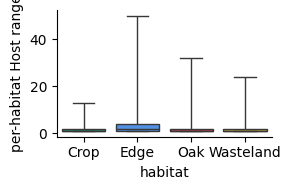

In [29]:
g = sns.catplot(
    host_range_byhabitat_melt,
    x='habitat', y='host_range', hue='habitat', height=2.0, aspect=1.5,
    palette=conf['habitat_palette'], kind='box', whis=100000000000.0
)
g.set_ylabels("per-habitat Host range")
# g.ax.set_yscale("log")

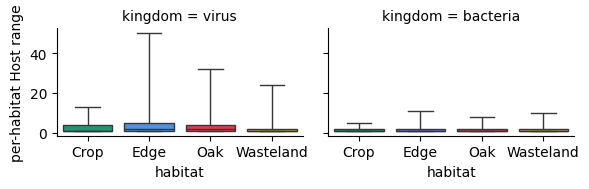

In [30]:
g = sns.catplot(
    host_range_byhabitat_melt,
    x='habitat', y='host_range', hue='habitat', height=2.0, aspect=1.5, col='kingdom',
    palette=conf['habitat_palette'], kind='box', whis=100000000000.0
)
g.set_ylabels("per-habitat Host range")

# g.ax.set_yscale("log")

In [31]:
test_1 = kruskal(
    host_range_byhabitat_melt.query('habitat == "Crop"')['host_range'].values,
    host_range_byhabitat_melt.query('habitat == "Edge"')['host_range'].values,
    host_range_byhabitat_melt.query('habitat == "Wasteland"')['host_range'].values,
    host_range_byhabitat_melt.query('habitat == "Oak"')['host_range'].values,
)
test_1

KruskalResult(statistic=12.207260303968576, pvalue=0.006705869969898488)

In [32]:
 test_1 = kruskal(
    host_range_byhabitat_melt.query('kingdom == "bacteria"').query('habitat == "Crop"')['host_range'].values,
    host_range_byhabitat_melt.query('kingdom == "bacteria"').query('habitat == "Edge"')['host_range'].values,
    host_range_byhabitat_melt.query('kingdom == "bacteria"').query('habitat == "Wasteland"')['host_range'].values,
    host_range_byhabitat_melt.query('kingdom == "bacteria"').query('habitat == "Oak"')['host_range'].values,
)
test_1

KruskalResult(statistic=5.355592327181353, pvalue=0.14753549282394848)

In [33]:
 test_1 = kruskal(
    host_range_byhabitat_melt.query('kingdom == "virus"').query('habitat == "Crop"')['host_range'].values,
    host_range_byhabitat_melt.query('kingdom == "virus"').query('habitat == "Edge"')['host_range'].values,
    host_range_byhabitat_melt.query('kingdom == "virus"').query('habitat == "Wasteland"')['host_range'].values,
    host_range_byhabitat_melt.query('kingdom == "virus"').query('habitat == "Oak"')['host_range'].values,
)
test_1

KruskalResult(statistic=12.710810114163174, pvalue=0.005305622886350606)

In [34]:
results = pd.DataFrame.from_records(
    [
        {
            "test": "KW", 
            "data": "Only positive habitat-host ranges",
            "H": test_1.statistic,
            "p-value": test_1.pvalue
        }
    ]
).T
results

,0
test,KW
data,Only positive habitat-host ranges
H,12.71081
p-value,0.005306


In [35]:
db.save_dataframe(host_range_byhabitat_melt, "d_HostRangebyHab", "Bacteria and virus host-ranges by habitat")

Saved d_HostRangebyHab to db.2025-10-27


### Post-hoc host-range by habitat

In [36]:
post_hoc_hostrange_by_habitat = []
for org in ['virus', 'bacteria', 'all']:
    if org != 'all':
        df = host_range_byhabitat_melt.query('kingdom == "{0}"'.format(org))
    else:
        df = host_range_byhabitat_melt.copy()
    for h1 in ['Crop', 'Edge', 'Wasteland', 'Oak']:
        for h2 in ['Crop', 'Edge', 'Wasteland', 'Oak']:
            if h1 != h2:
                kw_h, pval = stats.mannwhitneyu(
                    df.query('habitat == "{0}"'.format(h1))['host_range'].values,
                    df.query('habitat == "{0}"'.format(h2))['host_range'].values,
                )
                significative = pval < 0.05
                post_hoc_hostrange_by_habitat.append(
                    {'kingdom': org, 'group_1': h1, 'group_2': h2, 'U': kw_h, 'p-val': pval, 'sign': significative}
            )
post_hoc_hostrange_by_habitat = pd.DataFrame.from_records(post_hoc_hostrange_by_habitat)

db.save_dataframe(
    df=post_hoc_hostrange_by_habitat, table_name="T_hostRangeByHabitat",
    description="Post-Hoc Mann Whitney U analysis on host range across different habitats and kingdoms"
)
si.save_dataframe(
    df=post_hoc_hostrange_by_habitat, table_name="TableS11",
    description="Mann-Whitney U post-hoc test on site-diversity by habitat"
)
post_hoc_hostrange_by_habitat

Saved T_hostRangeByHabitat to db.2025-10-27
Saved TableS11 to si.2025-10-27


,kingdom,group_1,group_2,U,p-val,sign
0,virus,Crop,Edge,2976.0,0.039092,True
1,virus,Crop,Wasteland,2093.5,0.241927,False
2,virus,Crop,Oak,1029.5,0.113178,False
3,virus,Edge,Crop,4256.0,0.039092,True
4,virus,Edge,Wasteland,4249.5,0.001590,True
5,virus,Edge,Oak,2235.5,0.890072,False
6,virus,Wasteland,Crop,1682.5,0.241927,False
7,virus,Wasteland,Edge,2417.5,0.001590,True
8,virus,Wasteland,Oak,835.5,0.012389,True
9,virus,Oak,Crop,1466.5,0.113178,False


In [37]:
db.conn.close()
si.conn.close()